#Mount the drive


In [77]:
import pandas as pd

In [78]:
df=pd.read_csv("/content/drive/MyDrive/AIML_lab_sem4/exp1/data.csv")

In [79]:
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
df.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [82]:
df.shape


(577, 18)

#Ques 1 . Team name normalization

1 Some team names appear in different textual formats (e.g., case differences or extra
spaces). Clean the team1 and team2 columns by:

2. Converting text to lowercase

3. Removing leading/trailing spaces

4. Verifying unique team names after cleaning

lower case all

In [83]:
df['team1'] = df['team1'].str.lower().str.strip()
df['team2'] = df['team2'].str.lower().str.strip()


In [84]:
df[['team1' , 'team2']]

,team1,team2
0,kolkata knight riders,royal challengers bangalore
1,chennai super kings,kings xi punjab
2,rajasthan royals,delhi daredevils
3,mumbai indians,royal challengers bangalore
4,deccan chargers,kolkata knight riders
...,...,...
572,delhi daredevils,royal challengers bangalore
573,gujarat lions,royal challengers bangalore
574,sunrisers hyderabad,kolkata knight riders
575,gujarat lions,sunrisers hyderabad


In [85]:
unique_teams = pd.concat([df['team1'], df['team2']]).unique()
unique_teams

array(['kolkata knight riders', 'chennai super kings', 'rajasthan royals',
       'mumbai indians', 'deccan chargers', 'kings xi punjab',
       'royal challengers bangalore', 'delhi daredevils',
       'kochi tuskers kerala', 'pune warriors', 'sunrisers hyderabad',
       'rising pune supergiants', 'gujarat lions'], dtype=object)

# City Name Standardization
Standardize the city column by:

1)Replacing missing city names with "Unknown"

2)Converting all city names to title case

3)Counting matches played in each city

In [86]:
df.isnull().sum()

,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [87]:
df['city'] = df['city'].fillna('Unknown')

In [88]:
df.isnull().sum()

,0
id,0
season,0
city,0
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [89]:
df['city']= df['city'].str.strip().str.title()

In [90]:
df['city']

,city
0,Bangalore
1,Chandigarh
2,Delhi
3,Mumbai
4,Kolkata
...,...
572,Raipur
573,Bangalore
574,Delhi
575,Delhi


In [91]:
city_counts = df['city'].value_counts()
city_counts

,count
city,
Mumbai,77
Bangalore,58
Kolkata,54
Delhi,53
Chennai,48
Chandigarh,42
Hyderabad,41
Jaipur,33
Pune,25


# 3. Toss Decision Text Analysis
Analyze the toss_decision column:

1)Extract unique decisions

2)Count how many times each decision was taken

3)Visualize the frequency using a bar chart

In [92]:
choice = df['toss_decision'].unique()
choice

array(['field', 'bat'], dtype=object)

In [93]:
dec = df['toss_decision'].value_counts()
dec

,count
toss_decision,
field,315
bat,262


<Axes: ylabel='count'>

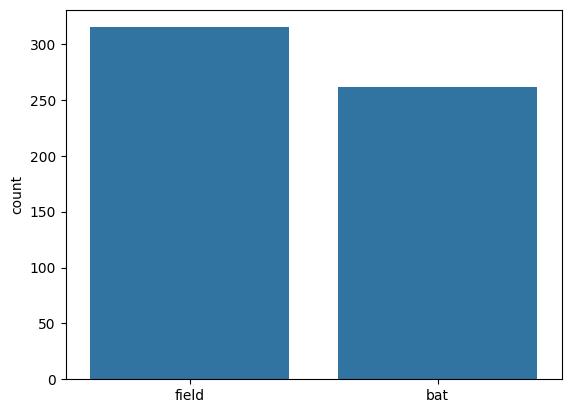

In [94]:
sns.barplot(x = choice , y = dec)


# 4, Winner Name Extraction

From the winner column:

1)Identify and remove rows where the match result was "No Result" or "Tie"

2)Count how many matches each team won after cleaning text values

In [95]:
df_temp = df[df['result'] != 'no result']
df_temp = df_temp[df_temp['result'] != 'tie']

In [96]:
winner_counts = df['winner'].str.lower().str.strip().value_counts()
print(winner_counts)

winner
mumbai indians                 80
chennai super kings            79
royal challengers bangalore    70
kolkata knight riders          68
rajasthan royals               63
kings xi punjab                63
delhi daredevils               56
sunrisers hyderabad            34
deccan chargers                29
pune warriors                  12
gujarat lions                   9
kochi tuskers kerala            6
rising pune supergiants         5
Name: count, dtype: int64


In [97]:
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,kolkata knight riders,royal challengers bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,chennai super kings,kings xi punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,rajasthan royals,delhi daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,mumbai indians,royal challengers bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,deccan chargers,kolkata knight riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN


# 5. Player of the Match Text Frequency
Perform text analysis on player of the match:

1)Remove null values

2)Find the top 10 most frequent player names

3)Plot the results using a Seaborn bar plot

In [98]:

pom_top_10 = df['player_of_match'].dropna().value_counts().head(10)



/tmp/ipython-input-2314669101.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pom_top_10.values, y=pom_top_10.index, palette='viridis')


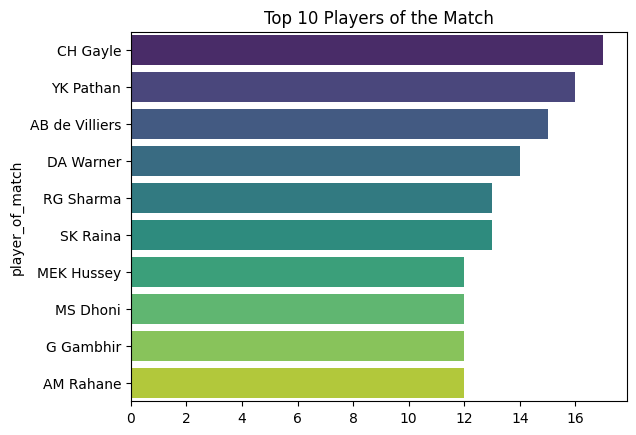

In [99]:
sns.barplot(x=pom_top_10.values, y=pom_top_10.index, palette='viridis')
plt.title('Top 10 Players of the Match')
plt.show()

# 6. Venue Tokenization

Count how many matches were played in each venue and plot a bar chart for the top
10.

/tmp/ipython-input-3597930040.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=venue_top_10.values, y=venue_top_10.index, palette='magma')


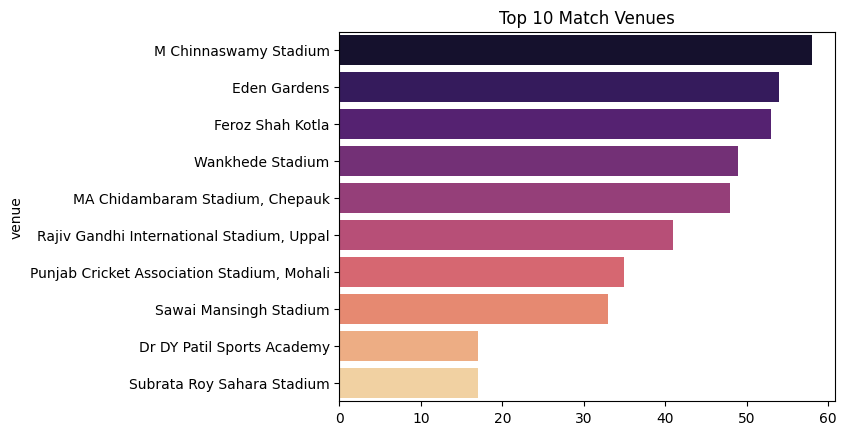

In [100]:

venue_top_10 = df['venue'].value_counts().head(10)

sns.barplot(x=venue_top_10.values, y=venue_top_10.index, palette='magma')
plt.title('Top 10 Match Venues')
plt.show()

# 7. Umpire Name Cleaning

Clean umpire columns (umpire1, umpire2, umpire3) by:

1)Replacing missing values with "Not Assigned"

2)Removing duplicate umpire names per match

3)Finding the most frequently officiating umpire

In [101]:
for col in ['umpire1', 'umpire2', 'umpire3']:
    df[col] = df[col].fillna('Not Assigned').str.strip()

In [102]:
all_umpires = pd.concat([df['umpire1'], df['umpire2'], df['umpire3']])

In [103]:
most_frequent = all_umpires[all_umpires != 'Not Assigned'].value_counts().idxmax()
print(f"Most frequently officiating umpire: {most_frequent}")

Most frequently officiating umpire: HDPK Dharmasena


# 8. Create a new text column match_summary by
combining:

team1, team2, winner, and season

Example: “MI vs CSK – MI won in 2019”

Display sample summaries.

In [104]:
def get_summary(row):
    return f"{str(row['team1'])} vs {str(row['team2'])} at {str(row['venue'])} won by {str(row['winner']).lower()}"

df['match_summary'] = df.apply(get_summary, axis=1)
print(df['match_summary'].head())

0    kolkata knight riders vs royal challengers ban...
1    chennai super kings vs kings xi punjab at Punj...
2    rajasthan royals vs delhi daredevils at Feroz ...
3    mumbai indians vs royal challengers bangalore ...
4    deccan chargers vs kolkata knight riders at Ed...
Name: match_summary, dtype: object


#9. Result Type Text Analysis

Analyze the result column:

Identify different textual result types

Count their occurrences

In [105]:
result_types = df['result'].value_counts()
result_types

,count
result,
normal,568
tie,6
no result,3


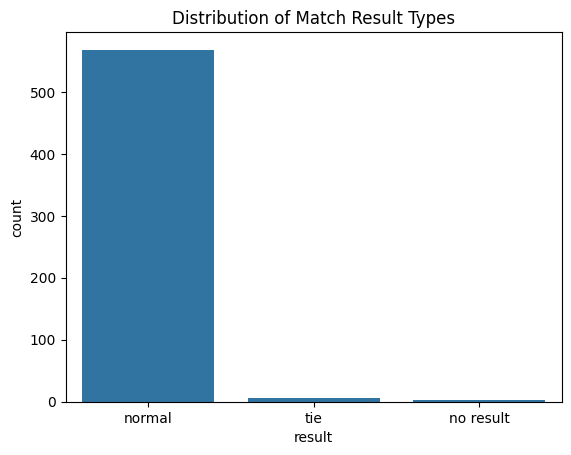

In [106]:
sns.countplot(data=df, x='result')
plt.title('Distribution of Match Result Types')
plt.show()

#10. Toss Winner vs Match Winner (Text Matching)

Compare text values in toss_winner and winner:

Create a boolean column indicating whether the toss winner also won the match
Visualize the comparison using a bar chart

In [107]:
df['toss_winner'] = df['toss_winner'].str.lower().str.strip()
df['winner'] = df['winner'].str.lower().str.strip() # Normalize winner column
df['toss_match_winner'] = df['toss_winner'] == df['winner']

comparison = df['toss_match_winner'].value_counts()
comparison

,count
toss_match_winner,
True,291
False,286


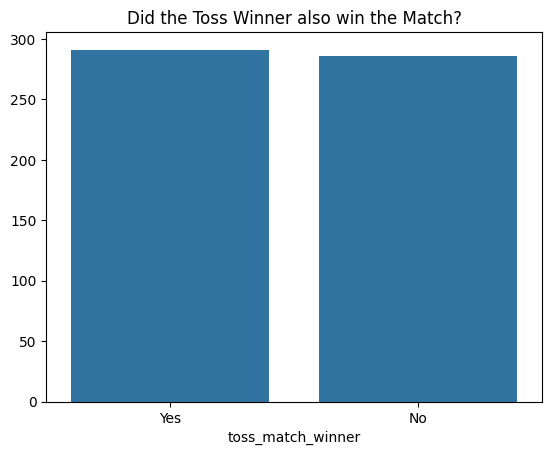

In [108]:

sns.barplot(x=comparison.index.map({True: 'Yes', False: 'No'}), y=comparison.values)
plt.title('Did the Toss Winner also win the Match?')
plt.show()

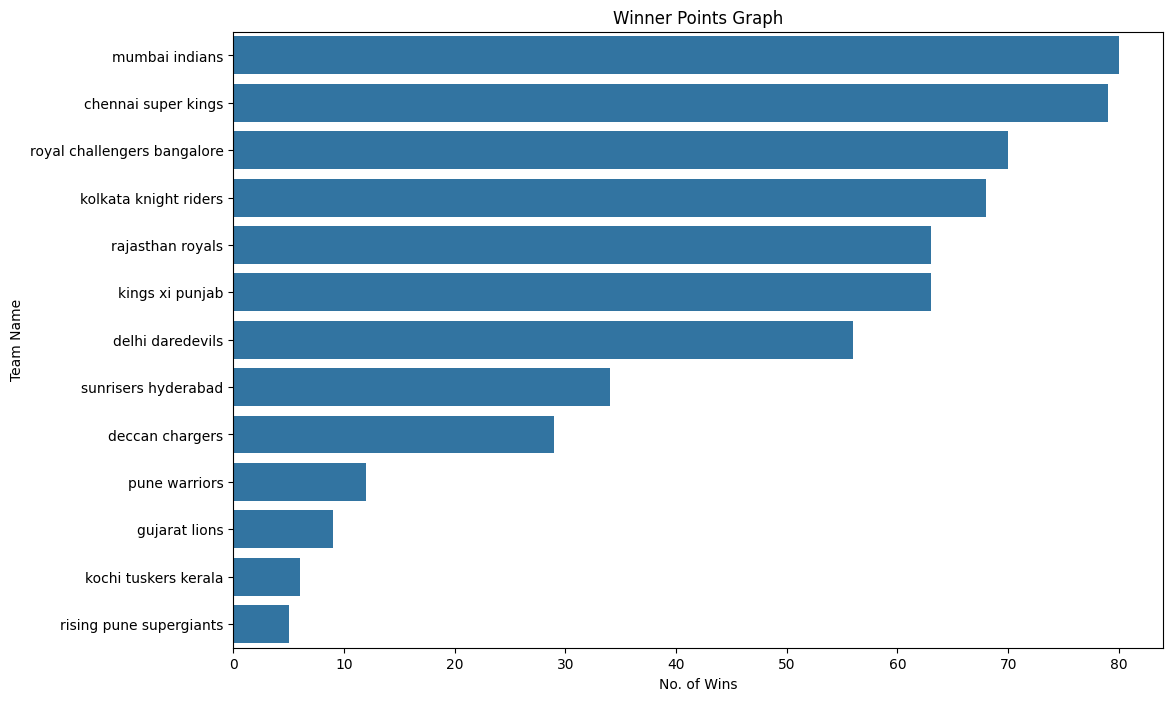

In [109]:
winner_counts = df['winner'].str.lower().str.strip().value_counts()
plt.figure(figsize=(12, 8))
sns.barplot(x=winner_counts.values, y=winner_counts.index)

plt.title('Winner Points Graph')
plt.xlabel('No. of Wins')
plt.ylabel('Team Name')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'mumbai indians'),
  Text(1, 0, 'chennai super kings'),
  Text(2, 0, 'royal challengers bangalore'),
  Text(3, 0, 'kolkata knight riders'),
  Text(4, 0, 'rajasthan royals'),
  Text(5, 0, 'kings xi punjab'),
  Text(6, 0, 'delhi daredevils'),
  Text(7, 0, 'sunrisers hyderabad'),
  Text(8, 0, 'deccan chargers'),
  Text(9, 0, 'pune warriors'),
  Text(10, 0, 'gujarat lions'),
  Text(11, 0, 'kochi tuskers kerala'),
  Text(12, 0, 'rising pune supergiants')])

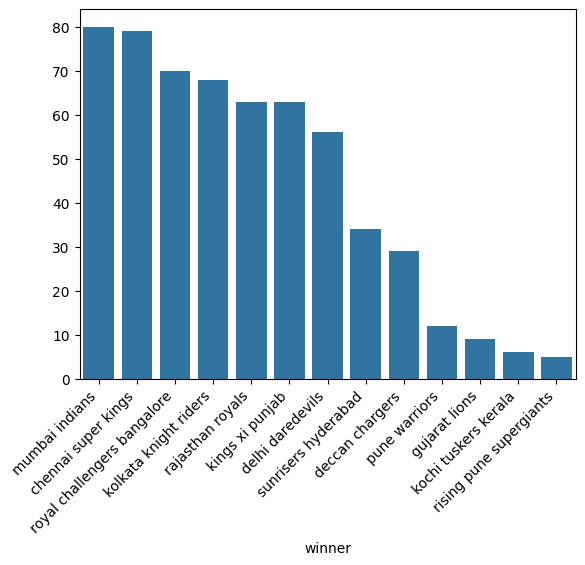

In [110]:
import seaborn as sns
sns.barplot(x= df['winner'].value_counts().index, y=df['winner'].value_counts().values)
plt.xticks(rotation=45,ha='right')